#Introduction


Please load the dataset and then run the file. The first half of the notebook preprocesses all of the datasets for easier distribution of work for the rest of the team members

# Sprint 1

## Loading data

In [ ]:
import pandas as pd

df_SDG1 = pd.read_excel("Twitter_Dataset_Assignment_2.xlsx", sheet_name='SDG1_No_Poverty')
df_SDG4 = pd.read_excel("Twitter_Dataset_Assignment_2.xlsx", sheet_name='SDG4_Quality_Education')
df_SDG5 = pd.read_excel("Twitter_Dataset_Assignment_2.xlsx", sheet_name='SDG5_Gender_Equality')
df_SDG7 = pd.read_excel("Twitter_Dataset_Assignment_2.xlsx", sheet_name='SDG7_Affordable_Clean_Energy')
df_SDG12 = pd.read_excel("Twitter_Dataset_Assignment_2.xlsx", sheet_name='SDG12_Responsible_Consumption')
df_SDG16 = pd.read_excel("Twitter_Dataset_Assignment_2.xlsx", sheet_name='SDG16_Peace_Justice_Institution')

print("SDG1 columns:", df_SDG1.columns.tolist())
df_SDG1.head()

SDG1 columns: ['SDG', 'Keyword', 'Tweet_ID', 'Username', 'User_ID', 'Text', 'Created_At', 'Hashtags', 'Language', 'Retweet_Count', 'Favorite_Count', 'Reply_Count', 'Quote_Count', 'Is_Quote_Status', 'Possibly_Sensitive', 'day', 'Text_Length']


,SDG,Keyword,Tweet_ID,Username,User_ID,Text,Created_At,Hashtags,Language,Retweet_Count,Favorite_Count,Reply_Count,Quote_Count,Is_Quote_Status,Possibly_Sensitive,day,Text_Length
0,SDG1_No_Poverty,Poverty Reduction,1915254371274645699,Amina J Mohammed,3066095291,Always inspiring to witness the work of the UN...,2025-04-24 04:00:00+00:00,NaN,en,4,19,1,0,False,0.0,2025-04-24,271
1,SDG1_No_Poverty,Poverty Reduction,1910371762073743388,Shavkat Mirziyoyev's Press-service,828136569915707392,President Shavkat #Mirziyoyev met with World B...,2025-04-10 16:38:15+00:00,"Mirziyoyev,Uzbekistan,Uzbekistan",en,6,42,15,0,False,0.0,2025-04-10,517
2,SDG1_No_Poverty,Poverty Reduction,1913321158684086483,Jody Toor,1732878652877176832,"📢 This week during Question Period, I had the ...",2025-04-18 19:58:06+00:00,"SeniorsSupport,LongTermCare,BCPolitics,VoiceFo...",en,4,10,1,1,False,0.0,2025-04-18,625
3,SDG1_No_Poverty,Poverty Reduction,1915358879422046578,Paul Akiwumi,1013781272420933632,I had engaging discussions w/ Ms. Paula Vazque...,2025-04-24 10:55:17+00:00,"EU,Mozambique",en,0,1,0,0,False,0.0,2025-04-24,309
4,SDG1_No_Poverty,Poverty Reduction,1915069666566770864,Peel Poverty Reduction Committee,1465727018,Did you know that Peel Newcomers are supported...,2025-04-23 15:46:03+00:00,ItsOurVote,en,0,2,0,0,False,NaN,2025-04-23,279


In [ ]:
df_SDG1_pre = df_SDG1[['Created_At', 'Text']]
df_SDG4_pre = df_SDG4[['Created_At', 'Text']]
df_SDG5_pre = df_SDG5[['Created_At', 'Text']]
df_SDG7_pre = df_SDG7[['Created_At', 'Text']]
df_SDG12_pre = df_SDG12[['Created_At', 'Text']]
df_SDG16_pre = df_SDG16[['Created_At', 'Text']]

## Standardizing the texts

In [ ]:
df_SDG1_pre['Text'] = df_SDG1_pre['Text'].str.lower()
df_SDG4_pre['Text'] = df_SDG4_pre['Text'].str.lower()
df_SDG5_pre['Text'] = df_SDG7_pre['Text'].str.lower()
df_SDG7_pre['Text'] = df_SDG7_pre['Text'].str.lower()
df_SDG12_pre['Text'] = df_SDG12_pre['Text'].str.lower()
df_SDG16_pre['Text'] = df_SDG16_pre['Text'].str.lower()

df_SDG1_pre.head()

/tmp/ipykernel_20124/2138446829.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_SDG1_pre['Text'] = df_SDG1_pre['Text'].str.lower()
/tmp/ipykernel_20124/2138446829.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_SDG4_pre['Text'] = df_SDG4_pre['Text'].str.lower()
/tmp/ipykernel_20124/2138446829.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pan

,Created_At,Text
0,2025-04-24 04:00:00+00:00,always inspiring to witness the work of the un...
1,2025-04-10 16:38:15+00:00,president shavkat #mirziyoyev met with world b...
2,2025-04-18 19:58:06+00:00,"📢 this week during question period, i had the ..."
3,2025-04-24 10:55:17+00:00,i had engaging discussions w/ ms. paula vazque...
4,2025-04-23 15:46:03+00:00,did you know that peel newcomers are supported...


## Removing random letters

In [ ]:
import re

def remove_twitter_noise(tweet):

    cleaned = re.sub(
        r"(@[A-Za-z0-9]+)|([^0-9A-Za-z \t])|(\w+:\/\/\S+)",
        "",
        str(tweet)
    )

    cleaned = re.sub(r"\s\s+", " ", cleaned)
    return cleaned


df_SDG1_pre['Text'] = df_SDG1_pre['Text'].apply(remove_twitter_noise)
df_SDG4_pre['Text'] = df_SDG4_pre['Text'].apply(remove_twitter_noise)
df_SDG5_pre['Text'] = df_SDG5_pre['Text'].apply(remove_twitter_noise)
df_SDG7_pre['Text'] = df_SDG7_pre['Text'].apply(remove_twitter_noise)
df_SDG12_pre['Text'] = df_SDG12_pre['Text'].apply(remove_twitter_noise)
df_SDG16_pre['Text'] = df_SDG16_pre['Text'].apply(remove_twitter_noise)
df_SDG1_pre.tail()

/tmp/ipykernel_20124/1528782368.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_SDG1_pre['Text'] = df_SDG1_pre['Text'].apply(remove_twitter_noise)
/tmp/ipykernel_20124/1528782368.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_SDG4_pre['Text'] = df_SDG4_pre['Text'].apply(remove_twitter_noise)
/tmp/ipykernel_20124/1528782368.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveat

,Created_At,Text
4480,2025-04-17 08:08:00+00:00,from land rights in paraguay to illegal loggin...
4481,2025-04-18 21:48:00+00:00,you are right the muslim aboriginal ambassado...
4482,2025-04-20 04:49:08+00:00,the claim about the indravelli massacre on apr...
4483,2025-04-22 21:18:25+00:00,he has done a lot for natives and land rights ...
4484,2025-04-17 13:19:07+00:00,its like the trail of tearspresident jackson w...


##Removing duplicates

In [ ]:
duplicate_count = df_SDG1_pre['Text'].duplicated().sum()
duplicate_count = df_SDG4_pre['Text'].duplicated().sum()
duplicate_count = df_SDG5_pre['Text'].duplicated().sum()
duplicate_count = df_SDG7_pre['Text'].duplicated().sum()
duplicate_count = df_SDG12_pre['Text'].duplicated().sum()
duplicate_count = df_SDG16_pre['Text'].duplicated().sum()
print(f"Duplicate tweets found: {duplicate_count}")

Duplicate tweets found: 99


In [ ]:
print(f"Rows before: {df_SDG1_pre.shape[0]}")
df_SDG1_pre = df_SDG1_pre.drop_duplicates(subset='Text', keep='first')
df_SDG4_pre = df_SDG4_pre.drop_duplicates(subset='Text', keep='first')
df_SDG5_pre = df_SDG5_pre.drop_duplicates(subset='Text', keep='first')
df_SDG7_pre = df_SDG7_pre.drop_duplicates(subset='Text', keep='first')
df_SDG12_pre = df_SDG12_pre.drop_duplicates(subset='Text', keep='first')
df_SDG16_pre = df_SDG16_pre.drop_duplicates(subset='Text', keep='first')

print(f"Rows after:  {df_SDG1_pre.shape[0]}")

Rows before: 4485
Rows after:  4361


## Removing stopwords

In [ ]:
import nltk

nltk.download('stopwords')

from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
stop_words = stopwords.words('english')
print(f"Stop words loaded: {stop_words}")
stop_words.remove('not')
print("'not' has been removed from the stop word list.")

Stop words loaded: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'sh

In [ ]:
def remove_stop_words(tweet):

    tokens = tweet.split()


    filtered_tokens = [word for word in tokens if word not in stop_words]


    return " ".join(filtered_tokens)


example = "you are the first person to visit today"
print("Before:", example)
print("After: ", remove_stop_words(example))

Before: you are the first person to visit today
After:  first person visit today


In [ ]:
df_SDG1_pre['Text'] = df_SDG1_pre['Text'].apply(remove_stop_words)
df_SDG4_pre['Text'] = df_SDG4_pre['Text'].apply(remove_stop_words)
df_SDG5_pre['Text'] = df_SDG5_pre['Text'].apply(remove_stop_words)
df_SDG7_pre['Text'] = df_SDG7_pre['Text'].apply(remove_stop_words)
df_SDG12_pre['Text'] = df_SDG12_pre['Text'].apply(remove_stop_words)
df_SDG16_pre['Text'] = df_SDG16_pre['Text'].apply(remove_stop_words)
df_SDG1_pre.tail(5)

,Created_At,Text
4480,2025-04-17 08:08:00+00:00,land rights paraguay illegal logging monitorin...
4481,2025-04-18 21:48:00+00:00,right muslim aboriginal ambassador jason moham...
4482,2025-04-20 04:49:08+00:00,claim indravelli massacre april 20 1981 accura...
4483,2025-04-22 21:18:25+00:00,done lot natives land rights lot harm us spira...
4484,2025-04-17 13:19:07+00:00,like trail tearspresident jackson trump idoliz...


## Visualizations

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


word_frequency = pd.Series(' '.join(df_SDG1_pre['Text']).split()).value_counts()


word_frequency[:10]

,count
amp,828
social,778
poverty,770
support,710
not,673
people,666
basic,607
income,522
financial,496
food,490


## Word Frequncy

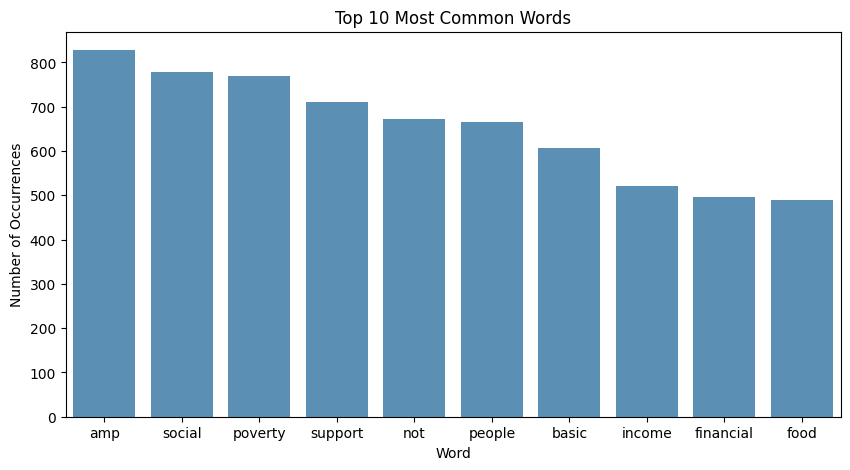

In [ ]:
top_words = word_frequency[:10]

plt.figure(figsize=(10, 5))
sns.barplot(x=top_words.index, y=top_words.values, alpha=0.8)
plt.title('Top 10 Most Common Words')
plt.xlabel('Word')
plt.ylabel('Number of Occurrences')
plt.show()

## Word cloud

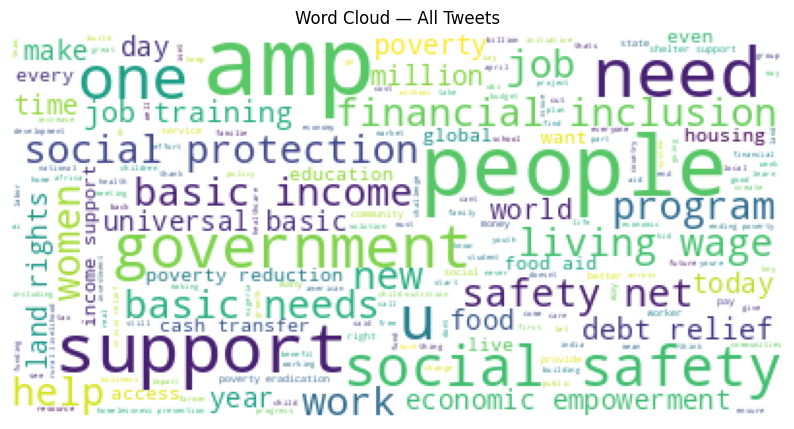

In [ ]:
from wordcloud import WordCloud  # Library for generating word cloud images

corpus = list(df_SDG1_pre['Text'])

wordcloud = WordCloud(background_color='white', max_words=200, max_font_size=50, random_state=42).generate(str(corpus))

plt.figure(figsize=(10, 6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Word Cloud — All Tweets')
plt.show()

In [ ]:
df_SDG4_pre.head()

,Created_At,Text
0,2025-04-12 14:38:53+00:00,josiah chinamano born epworth mission near sal...
1,2025-04-15 17:20:49+00:00,inside neverending clamor school fundingwho fu...
2,2025-04-21 15:10:45+00:00,classical school enrollment surges learning cr...
3,2025-04-18 12:27:23+00:00,bridging digital divide empowering rural youth...
4,2025-03-23 04:26:08+00:00,chatgpt highlights radical il bill must stoppe...


# Sprint 2

## N-gram Analysis

### Bi-grams

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer


def get_ngrams(corpus, ngram_range=(2, 2)):

    vectorizer = CountVectorizer(ngram_range=ngram_range, max_features=2000).fit(corpus)


    word_count_matrix = vectorizer.transform(corpus)


    total_counts = word_count_matrix.sum(axis=0)


    ngram_freq = [
        (phrase, int(total_counts[0, index]))
        for phrase, index in vectorizer.vocabulary_.items()
    ]


    ngram_freq = sorted(ngram_freq, key=lambda pair: pair[1], reverse=True)

    return ngram_freq

In [ ]:
bigrams_SDG12 = get_ngrams(df_SDG12_pre['Text'].tolist(), ngram_range=(2, 2))

bigrams_SDG12[:5]

[('carbon footprint', 646),
 ('circular economy', 390),
 ('food waste', 342),
 ('fair trade', 240),
 ('supply chain', 234)]

/tmp/ipykernel_20124/3475983458.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


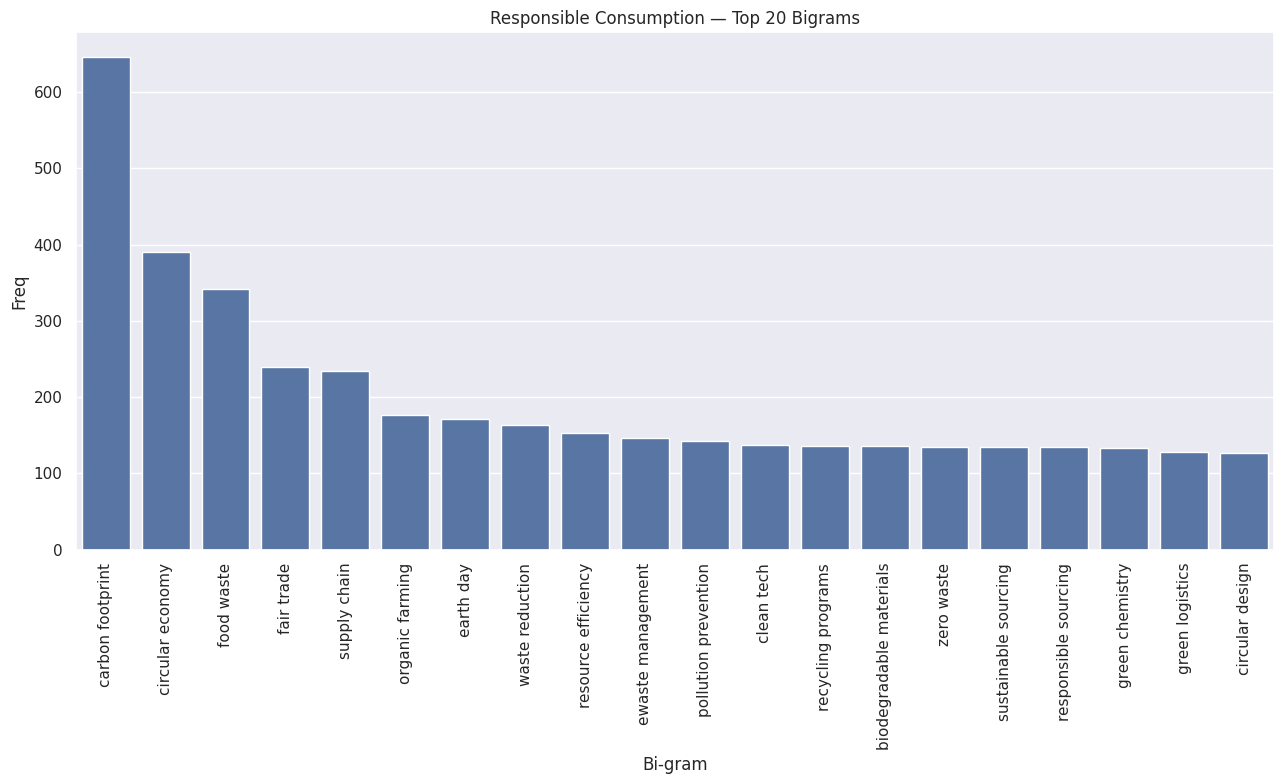

In [ ]:
bigrams_telstra_df = pd.DataFrame(bigrams_SDG12, columns=['Bi-gram', 'Freq'])

top_n = 20

sns.set(rc={'figure.figsize': (13, 8)})
chart = sns.barplot(x='Bi-gram', y='Freq', data=bigrams_telstra_df[:top_n])
chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
plt.title('Responsible Consumption — Top 20 Bigrams')
plt.tight_layout()
plt.show()

* **Carbon footprint (646)** is the most frequent bigram, showing that environmental impact awareness is the dominant discussion theme within SDG12 tweets. This suggests users strongly associate responsible consumption with reducing emissions and sustainability accountability.

* **Circular economy (390)** appears as the second most common bigram, indicating strong discussion around reuse, recycling, and sustainable production systems rather than traditional linear consumption models.

* **Food waste (342)** confirms that waste reduction is a major concern among users, supporting its selection as a focused topic for deeper NLP analysis such as sentiment and topic classification.

* **Fair trade (240)** highlights consumer concern regarding ethical sourcing, labor conditions, and responsible purchasing decisions, linking sustainability with social responsibility.

* **Supply chain (234)** suggests that users also connect SDG12 with production transparency, logistics efficiency, and corporate responsibility in sustainable manufacturing practices.


### Tri-grams

/tmp/ipykernel_20124/892970721.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


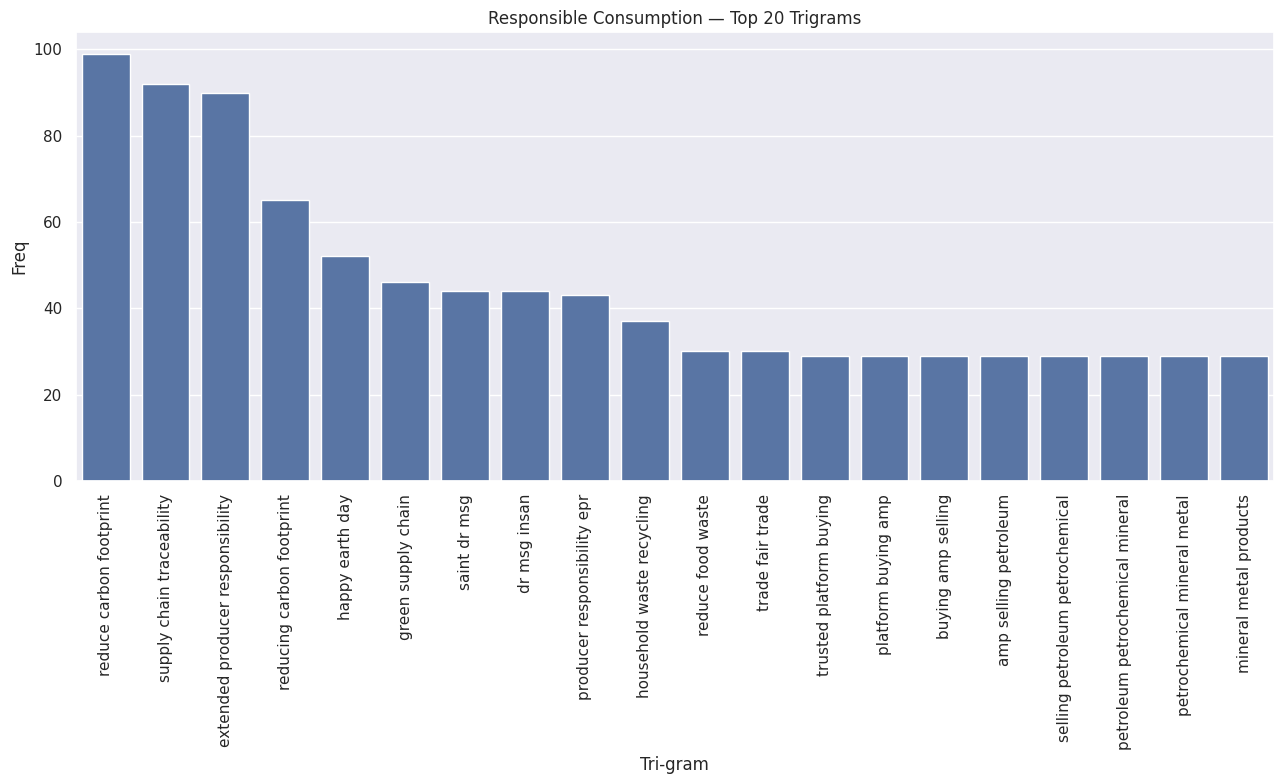

In [ ]:
trigrams_SDG12 = get_ngrams(df_SDG12_pre['Text'].tolist(), ngram_range=(3, 3))

trigrams_SDG12_df = pd.DataFrame(trigrams_SDG12, columns=['Tri-gram', 'Freq'])

top_n = 20

chart = sns.barplot(x='Tri-gram', y='Freq', data=trigrams_SDG12_df[:top_n])
chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
plt.title('Responsible Consumption — Top 20 Trigrams')
plt.tight_layout()
plt.show()

* **Reduce carbon footprint** is the most frequent trigram, showing that the strongest public focus within SDG12 discussions is on lowering environmental impact and promoting sustainable daily consumption habits.

* **Supply chain traceability** appears prominently, indicating that users are highly concerned with transparency in production processes, ethical sourcing, and how products move through sustainable supply chains.

* **Extended producer responsibility** highlights awareness of corporate accountability, where producers are expected to manage the environmental impact of products even after consumer use.

* **Reducing carbon footprint** reinforces the dominance of climate-conscious discussions, suggesting that sustainability conversations are strongly linked to emission reduction and eco-friendly lifestyles.

* **Household waste recycling** and **reduce food waste** show that personal-level actions such as recycling, composting, and reducing food waste are central to responsible consumption behaviour.

* **Green supply chain** and **fair trade fair trade** suggest that users also connect SDG12 with ethical trade, sustainable logistics, and fair production systems rather than only individual consumer habits.

* Overall, the trigram analysis shows that SDG12 discussions are driven by both **individual responsibility** (food waste, recycling, carbon reduction) and **corporate responsibility** (producer responsibility, supply chain traceability, fair trade).


##Temporal Analysis

In [ ]:
df_SDG12_daily = df_SDG12_pre.groupby(['Created_At'])['Text'].count().reset_index(name='tweet_count_SDG12').set_index('Created_At')

df_SDG12_daily.tail()

,tweet_count_SDG12
Created_At,
2025-04-25 06:23:53+00:00,1
2025-04-25 06:29:39+00:00,1
2025-04-25 06:36:55+00:00,1
2025-04-25 06:37:46+00:00,1
2025-04-25 06:58:17+00:00,1


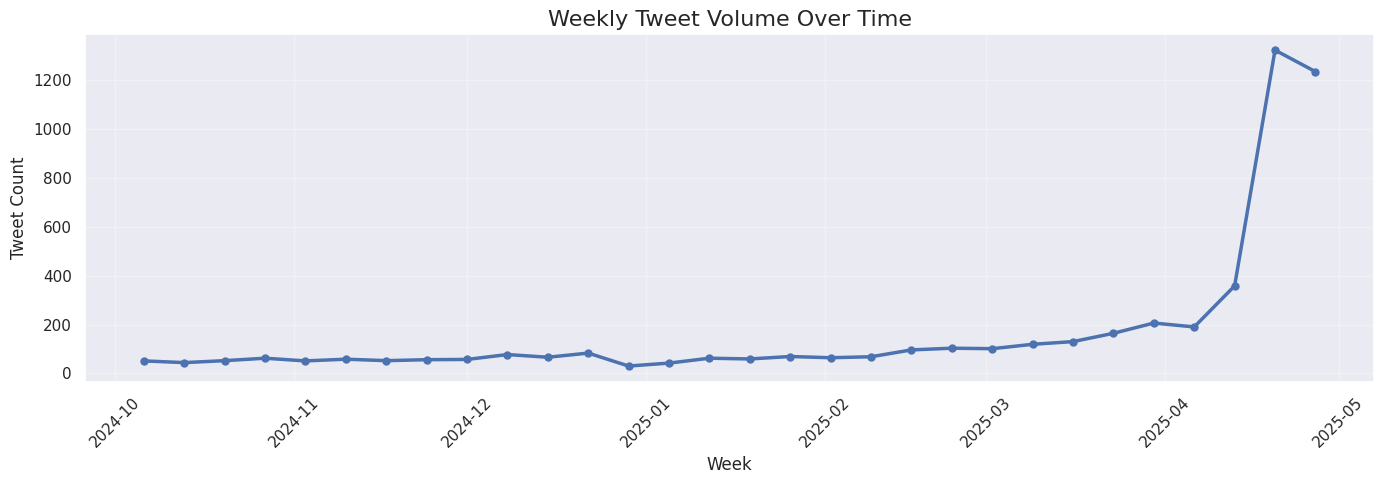

Chart saved as 'weekly_temporal_analysis.png'


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


df_SDG12_pre["Created_At"] = pd.to_datetime(
    df_SDG12_pre["Created_At"],
    errors="coerce"
)


df_SDG12_pre = df_SDG12_pre.dropna(subset=["Created_At"])


df_SDG12_weekly = (
    df_SDG12_pre
    .set_index("Created_At")
    .resample("W")
    .size()
    .reset_index(name="tweet_count_SDG12")
)


plt.figure(figsize=(14, 5))

plt.plot(
    df_SDG12_weekly["Created_At"],
    df_SDG12_weekly["tweet_count_SDG12"],
    linewidth=2.5,
    marker="o",
    markersize=5
)

plt.title("Weekly Tweet Volume Over Time", fontsize=16)
plt.xlabel("Week", fontsize=12)
plt.ylabel("Tweet Count", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("weekly_temporal_analysis.png", dpi=300)
plt.show()

print("Chart saved as 'weekly_temporal_analysis.png'")

* The weekly tweet volume remains relatively stable from October 2024 to February 2025, with tweet counts generally ranging between 40 and 100 tweets per week. This suggests steady but moderate discussion around responsible consumption topics during this period.

* From March 2025 onward, there is a noticeable upward trend, indicating increasing public engagement with SDG12-related discussions, particularly around sustainability, waste reduction, and ethical consumption.

* A significant spike occurs in April 2025, where tweet volume rises sharply from around 350 tweets to over 1300 tweets in a single week. This suggests a major event, campaign, viral discussion, or sustainability-related controversy triggered sudden public attention.

* Even after the highest peak, tweet volume remains very high (above 1200), showing that the discussion was not temporary but continued strongly over multiple weeks, indicating sustained public interest.

* This spike is particularly useful for deeper analysis because examining tweets from this period can help identify the main drivers of public discourse, such as food waste campaigns, environmental awareness events, corporate sustainability issues, or policy announcements.

* Overall, the temporal analysis shows that responsible consumption discussions intensified significantly over time, with April 2025 representing the most critical discussion period within the dataset.


/tmp/ipykernel_20124/2107790282.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


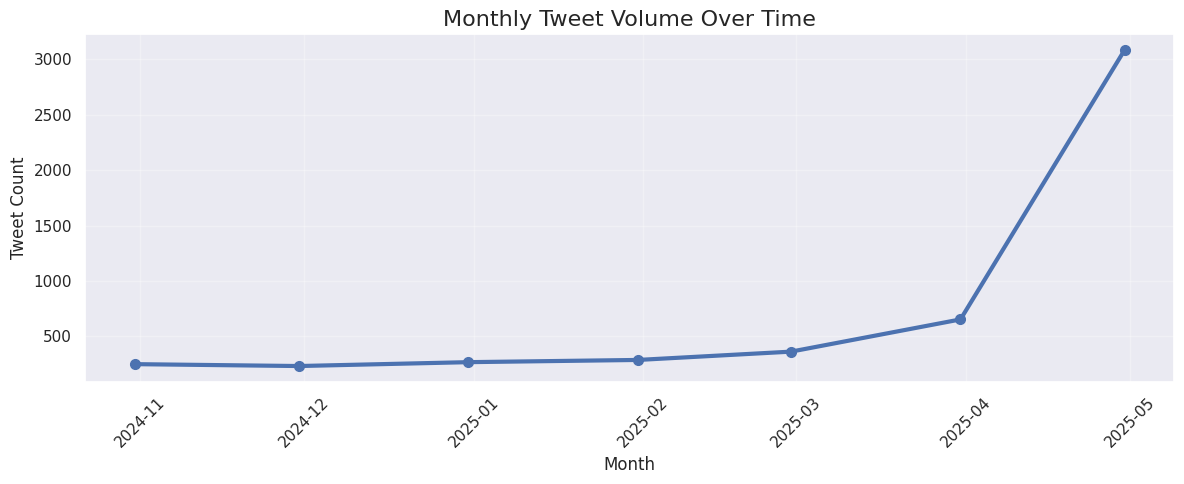

Chart saved as 'monthly_temporal_analysis.png'


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


df_SDG12_pre["Created_At"] = pd.to_datetime(
    df_SDG12_pre["Created_At"],
    errors="coerce"
)


df_SDG12_pre = df_SDG12_pre.dropna(subset=["Created_At"])


df_SDG12_monthly = (
    df_SDG12_pre
    .set_index("Created_At")
    .resample("M")
    .size()
    .reset_index(name="tweet_count_SDG12")
)


plt.figure(figsize=(12, 5))

plt.plot(
    df_SDG12_monthly["Created_At"],
    df_SDG12_monthly["tweet_count_SDG12"],
    linewidth=3,
    marker="o",
    markersize=7
)

plt.title("Monthly Tweet Volume Over Time", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Tweet Count", fontsize=12)

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("monthly_temporal_analysis.png", dpi=300)
plt.show()

print("Chart saved as 'monthly_temporal_analysis.png'")

A smoother graph for better interpretation of the data

In [ ]:
import pandas as pd


df_SDG12["Created_At"] = pd.to_datetime(df_SDG12["Created_At"], errors="coerce")


df_SDG12 = df_SDG12.dropna(subset=["Created_At"])


df_SDG12["week"] = df_SDG12["Created_At"].dt.to_period("W").dt.start_time


weekly_counts = (
    df_SDG12
    .groupby("week")
    .size()
    .reset_index(name="tweet_count")
)


spike_week = weekly_counts.loc[weekly_counts["tweet_count"].idxmax(), "week"]
spike_count = weekly_counts.loc[weekly_counts["tweet_count"].idxmax(), "tweet_count"]

print(f"Highest weekly spike: week starting {spike_week.date()}")
print(f"Number of tweets in spike week: {spike_count}\n")


spike_tweets = df_SDG12[df_SDG12["week"] == spike_week]["Text"]

print(f"Tweets from spike week starting {spike_week.date()}:\n")

for tweet in spike_tweets:
    print("-", tweet)

Highest weekly spike: week starting 2025-04-14
Number of tweets in spike week: 1354

Tweets from spike week starting 2025-04-14:

- 24 of 27 EU countries have developed circular economy strategies, but progress is slow.

A circular economy approach – where resources are reused, repaired &amp; recycled –could cut emissions by up to 70% by 2050 and reduce waste in cities.

🔗https://t.co/PYRtRP1ug3 | #OECDUrbanDays https://t.co/b0aFGPI20t
- ♻️ Aduro is in Montréal for the Canadian Circular Economy Summit!

Our Head of Corporate Development and Investor Relations, Abe Dyck, is on the ground connecting with fellow innovators, investors, and policy leaders working to accelerate Canada’s shift to a circular future. 🌍

We are proud to be part of this important national conversation on advancing sustainable tech and circular solutions.

Learn more about #CCES2025: https://t.co/1dqkLq8YZA

#CircularEconomy #CleanTech #EcoInnovation
- Telangana Govt. collaborates with leading Japanese Eco Town co

/tmp/ipykernel_20124/2233699189.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_SDG12["week"] = df_SDG12["Created_At"].dt.to_period("W").dt.start_time


##Sentiment Analysis

In [ ]:
from textblob import TextBlob

def get_sentiment(tweet):
    return TextBlob(tweet).sentiment.polarity


df_SDG12['sentiment'] = df_SDG12['Text'].apply(get_sentiment)

df_SDG12[['Text', 'sentiment']].head(20)

,Text,sentiment
0,Primus Partners in UAE is translating sustaina...,0.150000
1,"As official partners of #ChangeNOW2025, we’re ...",0.250000
2,Outcome of a national challenge organised by @...,0.000000
3,"This #WorldEarthDay, we at Tata Chemicals affi...",0.000000
4,We crossed the borough border to visit Lewisha...,0.700000
5,🌊 Is deep-sea #mining worth the risk? A new PL...,0.233939
6,$iag Circular Economy is Growing Daily\n\nFrom...,0.000000
7,We’re thrilled to announce the launch of Plast...,0.366667
8,24 of 27 EU countries have developed circular ...,-0.133333
9,Cobalt is more than just a metal – it’s a driv...,0.166667


In [ ]:
df_SDG12.groupby(['Text'])['sentiment'].mean()

,sentiment
Text,
"""Anointed preacher, teacher and prophet of God"" poisoned his wife and locked his daughter up with her dying mother.",0.000000
"""Builders on Algorand are creating protocols &amp; companies that solve important problems at a global scale: instant payments in war &amp; disaster zones, self-sovereign identity for the disenfranchised, supply-chain traceability for global commerce, etc."" #BlockchainForGood",0.100000
"""Climatologists say the joy ride released 1,000 tons of CO2 into the atmosphere, which is the annual carbon footprint of 100 households, but please do your recycling, okay? The climate crisis is your fault!""",0.712500
"""Do not give in to this carbon footprint thing. It is all just control.""\n\nJoe Rogan critiques ""green"" energy initiatives, carbon taxes, and the human-induced climate change narrative—framing them as tools in a broader agenda to exert control over the population.\n\nCredit: @joerogan",-0.200000
"""EU and India looking to significantly scale up cooperation in clean tech, semi-conductors, defence and security,""says EU ambassador to India Hervé Delphin @EU_in_India @EUAmbIndia on India EU FTA",0.370833
...,...
"🪙VESTN stands for a better tomorrow , where blockchain drives real innovation and supports sustainability.\nToday, we honor Earth Day by renewing our dedication to a more eco-friendly Web3 space.\n\n💚 Let’s create decentralized solutions that protect our planet.\n💡 Clean tech. https://t.co/RpO0hSfHrH",0.391667
"🪴♻️ We had such a fantastic time at last weekend's Seedy Saturday &amp; Waste Reduction Event, hosted by @scadding_court. \n\nOur ambassadors hosted an info table and led a waste reduction workshop. We all left feeling pretty inspired! https://t.co/JA28vTSocb",0.044643
"🪵📦 Bpacks logs €1M pre-seed funding for world’s first bark-based, 100% compostable packaging. https://t.co/TcTtrnx8v2\n#tech #funding #news #sustainability",0.250000


In [ ]:
df_senti_SDG12 = df_SDG12.groupby(['day'])['sentiment'].mean().reset_index(name='SDG12 mean_sentiment').set_index('day')

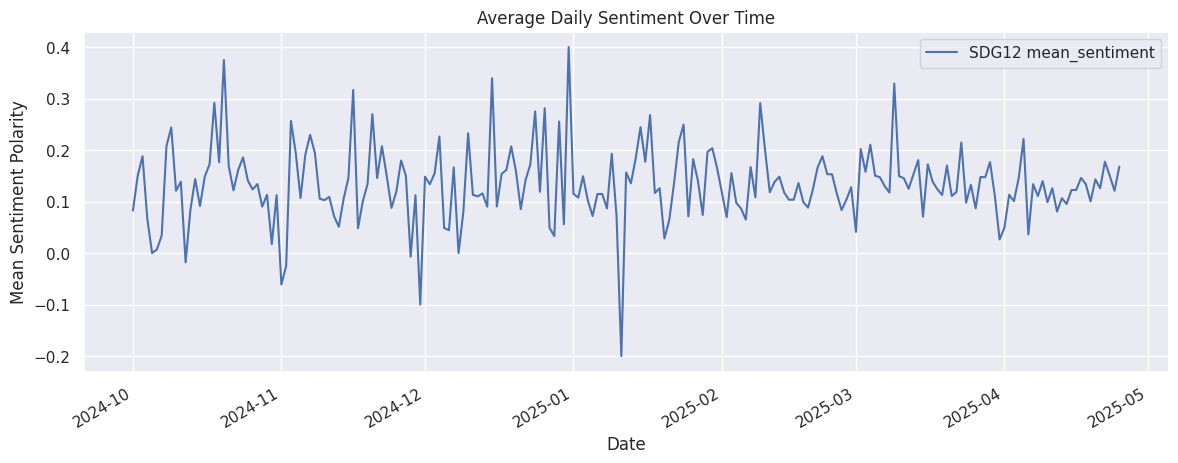

In [ ]:
ax = df_senti_SDG12.plot(figsize=(14, 5))
plt.title('Average Daily Sentiment Over Time')
plt.xlabel('Date')
plt.ylabel('Mean Sentiment Polarity')
plt.savefig('sentiment_timeline.png', dpi=800)
plt.show()

* The average daily sentiment remains mostly **positive throughout the observed period**, with sentiment polarity generally staying between 0.05 and 0.20. This indicates that public discussions around responsible consumption and SDG12 are largely supportive and optimistic.

* Several positive peaks are visible, especially between October 2024 and January 2025, where sentiment rises above 0.30 and even reaches approximately 0.40. These peaks likely reflect strong positive reactions to sustainability campaigns, environmental awareness events, or successful corporate sustainability initiatives.

* A noticeable negative dip occurs around mid-January 2025, where sentiment falls below zero to nearly -0.20. This suggests a short period of criticism or concern, possibly related to environmental controversies, policy failures, or public dissatisfaction with sustainability practices.

* After this negative drop, sentiment quickly returns to positive levels, indicating that negative discussions were temporary and did not dominate the overall conversation.

* From February to April 2025, sentiment becomes more stable, fluctuating within a narrower positive range. This suggests that discussions shifted from strong emotional reactions toward more consistent and balanced engagement with responsible consumption topics.

* Overall, the sentiment trend demonstrates that while occasional criticism exists, public perception of responsible consumption remains predominantly positive, with sustainability initiatives generally receiving favorable attention on Twitter.


##Topic Modelling

### Text Corpus

In [ ]:
corpus = list(df_SDG12['Text'])

print(f"Number of documents (tweets): {len(corpus)} \n")

corpus[:5]

Number of documents (tweets): 5273 



['Primus Partners in UAE is translating sustainability goals into tangible progress through focused action. The Circular Economy Policy lays the foundation for responsible consumption and production, https://t.co/Stzwwyacl6',
 'As official partners of #ChangeNOW2025, we’re bringing bold ideas to the stage⚡\n\n🎤 April 25 – Circular Economy (side event)\n🎤 April 26 – Main stage: Rebuilding the Essentials\n\nImmersive experiences: Climate Sense &amp; Fresk Workshops\n\n#ElectrifyTheFuture #CircularEconomy https://t.co/ypUSZEoKp2',
 'Outcome of a national challenge organised by @CouncilCircular, in support of @GoI_MeitY &amp; @PrinSciAdvGoI\nIt is aimed at identifying and showcasing groundbreaking solutions that align with the principles of the circular economy &amp; have potential for waste-to-wealth innovations. https://t.co/Gjc0jWvWkD',
 'This #WorldEarthDay, we at Tata Chemicals affirm our commitment to sustainability — integrating eco-friendly practices across our operations.\n\nFrom 

###Tokenise

In [ ]:
SDG12_texts = [str(tweet).split() for tweet in corpus]

print("Original tweet:", corpus[0])
print("Tokenised:     ", SDG12_texts[0])

Original tweet: Primus Partners in UAE is translating sustainability goals into tangible progress through focused action. The Circular Economy Policy lays the foundation for responsible consumption and production, https://t.co/Stzwwyacl6
Tokenised:      ['Primus', 'Partners', 'in', 'UAE', 'is', 'translating', 'sustainability', 'goals', 'into', 'tangible', 'progress', 'through', 'focused', 'action.', 'The', 'Circular', 'Economy', 'Policy', 'lays', 'the', 'foundation', 'for', 'responsible', 'consumption', 'and', 'production,', 'https://t.co/Stzwwyacl6']


###Dictionary


In [ ]:
!pip install gensim

from gensim import corpora

dictionary = corpora.Dictionary(SDG12_texts)

print(f"Vocabulary size: {len(dictionary)} unique words")

Vocabulary size: 48101 unique words


In [ ]:
print("Tweet tokens:      ", sorted(SDG12_texts[0]))
print("BoW representation:", dictionary.doc2bow(SDG12_texts[0]))

Tweet tokens:       ['Circular', 'Economy', 'Partners', 'Policy', 'Primus', 'The', 'UAE', 'action.', 'and', 'consumption', 'focused', 'for', 'foundation', 'goals', 'https://t.co/Stzwwyacl6', 'in', 'into', 'is', 'lays', 'production,', 'progress', 'responsible', 'sustainability', 'tangible', 'the', 'through', 'translating']
BoW representation: [(0, 1), (1, 1), (2, 1), (3, 1), (4, 1), (5, 1), (6, 1), (7, 1), (8, 1), (9, 1), (10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (16, 1), (17, 1), (18, 1), (19, 1), (20, 1), (21, 1), (22, 1), (23, 1), (24, 1), (25, 1), (26, 1)]


In [ ]:
dictionary[0]

'Circular'

* The corpus dictionary contains **48,101 unique words**, indicating a large and diverse vocabulary within the SDG12 Twitter dataset. This suggests that discussions around responsible consumption involve a wide range of themes, industries, and sustainability concerns.

* The sample tweet tokens show words such as **Circular, Economy, Policy, UAE, Partners, and consumption**, which confirms that policy discussions and circular economy concepts are major components of the dataset.

* The **Bag of Words (BoW) representation** converts each tweet into a numerical format by assigning each unique word an ID and counting its frequency within the tweet. This is an important preprocessing step for topic modelling techniques such as LDA (Latent Dirichlet Allocation).

* For example, the token **“Circular”** is assigned dictionary ID 0, and the BoW output `[(0,1)]` means that the word appears once in that specific tweet.

* This transformation allows machine learning models to process text mathematically rather than as raw sentences, enabling deeper analysis of hidden themes and topic structures across thousands of tweets.

* Overall, the dictionary and BoW preparation provide the foundation for advanced NLP methods by transforming unstructured Twitter text into structured numerical data suitable for topic modelling and semantic analysis.


###Frequency Features


In [ ]:
corpus_bow = [dictionary.doc2bow(tweet_tokens) for tweet_tokens in SDG12_texts]

In [ ]:
from gensim import models

tfidf_model = models.TfidfModel(corpus_bow)
corpus_tfidf = tfidf_model[corpus_bow]

In [ ]:
total_topics = 40

lda_model = models.LdaModel(corpus_bow, id2word=dictionary, num_topics=total_topics)

corpus_lda = lda_model[corpus_tfidf]

print(f"LDA model trained with {total_topics} topics.")

LDA model trained with 40 topics.


In [ ]:
for topic_id, topic_words in lda_model.show_topics(total_topics, num_words=6):
    print(f"Topic {topic_id:2d}: {topic_words}")

Topic  0: 0.011*"e-waste" + 0.009*"&amp;" + 0.008*"First" + 0.008*"the" + 0.007*"AM" + 0.006*"pros"
Topic  1: 0.030*"and" + 0.022*"the" + 0.022*"to" + 0.019*"a" + 0.016*"of" + 0.011*"for"
Topic  2: 0.055*"Trade" + 0.009*"for" + 0.008*"the" + 0.007*"Producer" + 0.007*"Responsibility" + 0.006*"and"
Topic  3: 0.010*"footprint" + 0.008*"the" + 0.007*"#SustainableFuture" + 0.007*"our" + 0.006*"in" + 0.006*"a"
Topic  4: 0.030*"of" + 0.027*"a" + 0.025*"the" + 0.019*"and" + 0.017*"to" + 0.010*"water"
Topic  5: 0.009*"the" + 0.005*"vs" + 0.005*"Australian" + 0.004*"to" + 0.004*"Committee" + 0.004*"Planning"
Topic  6: 0.026*"and" + 0.025*"to" + 0.020*"the" + 0.013*"Prevention" + 0.013*"tourism" + 0.013*"of"
Topic  7: 0.008*"🧪" + 0.008*"speed" + 0.007*"and" + 0.006*"Token" + 0.006*"representatives" + 0.005*"compostable"
Topic  8: 0.016*"to" + 0.015*"and" + 0.012*"the" + 0.009*"cutting-edge" + 0.008*"a" + 0.008*"in"
Topic  9: 0.010*"coal" + 0.007*"THE" + 0.006*"Inc." + 0.006*"to" + 0.005*"Check" +

In [ ]:
!pip install pyLDAvis

In [ ]:
import pyLDAvis.gensim_models
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

pyLDAvis.enable_notebook()
panel = pyLDAvis.gensim_models.prepare(lda_model, corpus_lda, dictionary, mds='tsne')
panel

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
31    -4.919601  1.521324       1        1  10.882197
6     -4.724278  1.246958       2        1   5.605450
18    -4.304308 -0.923847       3        1   5.572859
36    -4.908903  1.487169       4        1   5.146173
25    -4.942076  1.531992       5        1   4.643956
21    -4.931420  1.466570       6        1   3.081633
29    -4.775443  0.492752       7        1   2.350230
33    -4.819138 -1.091965       8        1   2.170168
37    -4.954133  1.524178       9        1   2.164238
15    -4.535028 -0.135721      10        1   2.066655
32    -5.244827  0.522950      11        1   1.991640
1     -4.912925  1.291964      12        1   1.989113
39    -4.929327 -0.113626      13        1   1.975982
17    -4.888237 -0.705770      14        1   1.963594
3     -4.969560 -0.607346      15        1   1.946425
12    -5.356036 -1.309827      16        1   1.903853
4     -5.019835  1.189140      17        1   1.890543
23    -4.736930  1.100738      18        1   1.867498
11    -4.378142 -0.792622      19        1   1.862809
2     -4.998064 -0.968843      20        1   1.853571
7     -4.879125 -0.924105      21        1   1.853571
5     -4.909278 -0.839197      22        1   1.853571
0     -4.906405 -1.208550      23        1   1.853571
8     -4.851062 -0.047442      24        1   1.853571
22    -4.797721 -0.738721      25        1   1.853571
20    -5.443978 -0.619067      26        1   1.853571
16    -4.966684  0.289729      27        1   1.853571
19    -4.844720 -0.498732      28        1   1.853571
10    -4.865977  1.397389      29        1   1.853571
9     -5.010062 -0.958487      30        1   1.853571
13    -4.854118 -0.897069      31        1   1.853571
14    -4.772469 -1.276268      32        1   1.853571
30    -4.878320 -1.017208      33        1   1.853571
28    -4.865707 -0.968681      34        1   1.853571
26    -4.216246 -0.191685      35        1   1.853571
27    -5.518938 -0.228362      36        1   1.853571
24    -4.807144 -0.741726      37        1   1.853571
34    -4.909844 -0.865474      38        1   1.853571
35    -5.375167 -0.582990      39        1   1.853571
38    -4.741795 -0.325581      40        1   1.853571, topic_info=        Term       Freq      Total Category  logprob  loglift
24       the  84.000000  84.000000  Default  30.0000  30.0000
22286  Trade   4.000000   4.000000  Default  29.0000  29.0000
50        of  47.000000  47.000000  Default  28.0000  28.0000
8        and  76.000000  76.000000  Default  27.0000  27.0000
1619       •   4.000000   4.000000  Default  26.0000  26.0000
...      ...        ...        ...      ...      ...      ...
86      with   0.339753  21.729146  Topic40  -5.4426  -0.1701
67        at   0.284765  12.871723  Topic40  -5.6192   0.1769
614     your   0.264378   9.547027  Topic40  -5.6934   0.4015
113        -   0.249435  10.468766  Topic40  -5.7516   0.2511
249    waste   0.235927   9.300190  Topic40  -5.8073   0.3138

[2320 rows x 6 columns], token_table=       Topic      Freq                Term
term                                      
16961      3  1.414030                "Our
8290       3  1.280711        #Interesting
8105      15  1.351919  #SustainableFuture
2739      33  1.412186    #circulareconomy
803        1  0.352316                   &
...      ...       ...                 ...
5429      35  0.527806                   ✅
757       32  0.570654                  ➡️
3502      19  1.032637                   📌
1406       5  0.852430                   🔹
4497      21  1.595665                   🧪

[556 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[32, 7, 19, 37, 26, 22, 30, 34, 38, 16, 33, 2, 40, 18, 4, 13, 5, 24, 12, 3, 8, 6, 1, 9, 23, 21, 17, 20, 11, 10, 14, 15, 31, 29, 27, 28, 25, 35, 36, 39])

* This is a **PyLDAvis visualization** of your LDA (Latent Dirichlet Allocation) topic modelling results. It helps explain the hidden topics inside your SDG12 Twitter dataset by showing how words group together into themes.

* The **left side (Intertopic Distance Map)** shows each topic as a circle (bubble). Each numbered bubble represents one topic discovered by the model. The size of the bubble shows how common that topic is in the dataset, while the distance between bubbles shows how similar or different topics are from each other. Topics that are close together are related, while topics far apart represent very different discussions.

* In your graph, **Topic 29** is selected and highlighted in red. It represents **1.9% of all tokens**, meaning it is a smaller but still meaningful discussion theme within the overall SDG12 conversation.

* The **right side (Top-30 Most Relevant Terms)** shows the most important words for Topic 29. The blue bars show how frequent the word is in the whole dataset, while the red bars show how strongly the word belongs specifically to Topic 29.

* Important words like **biodegradable, sustainable, waste, reduce, materials, packaging** strongly suggest that Topic 29 is about **sustainable packaging and biodegradable waste management**. This likely represents discussions around eco-friendly materials, reducing packaging waste, and responsible product design.

* Some common words like “the,” “and,” and “to” still appear because stopword cleaning may not be fully complete. However, the meaningful terms clearly show the main sustainability theme of this topic.

* You can use this visualization to identify major themes across the dataset by clicking different topic bubbles and examining their top terms. For example, one topic may focus on food waste, another on circular economy, and another on supply chain sustainability.

* This helps transform thousands of tweets into understandable themes without manually reading every tweet. It is especially useful for explaining what people are discussing most under SDG12.

* For your report, you can write:

> LDA topic modelling was used to identify hidden discussion themes within SDG12-related tweets. PyLDAvis was used to visualize topic separation and interpret the most relevant terms for each topic. Topic 29 highlighted discussions around biodegradable packaging, sustainable materials, and waste reduction, indicating strong public attention toward sustainable product design and responsible consumption practices.


##NLP Model Selection

### Public sentiment on Food waste and overconsumption

In [ ]:
import pandas as pd

keywords = [
    "food waste",
    "waste food",
    "leftover food",
    "food sustainability",
    "zero waste",
    "sustainable eating",
    "food recycling",
    "composting",
    "expired food",
    "restaurant waste",
    "supermarket waste",
    "meal waste",
    "consumer waste",
    "reduce waste",
    "food disposal"
]

pattern = "|".join(keywords)

df_food_waste = df_SDG12_pre[
    df_SDG12_pre["Text"].str.contains(
        pattern,
        case=False,
        na=False
    )
].copy()

print("Total filtered tweets:", len(df_food_waste))
print(df_food_waste[["Text"]].head(10))

Total filtered tweets: 523
                                                  Text
8    24 27 eu countries developed circular economy ...
10   india wastes 40 food causing significant econo...
43   circular economy rethinking waste moving linea...
44   meet committee powering zero waste stories ban...
59   pillar iv africas green minerals strategy dedi...
110  leading scotlands journey circular economy hel...
168  72 100b tons materials world consumes every ye...
203  five key sectors targeted eus circular economy...
251  supply chain drive real social impact amp clai...
350  green practices key business successreduce was...


I filtered the words because I wanted to focus on a specific niche such as overconsumption in food. So I choose keywords to explore within the database. Based on those keywords I found 523 matching tweets

In [ ]:
from transformers import pipeline
import pandas as pd

# Load sentiment model
sentiment_model = pipeline(
    "text-classification",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest"
)

# Function to predict sentiment
def get_sentiment(text):
    try:
        result = sentiment_model(str(text[:512]))  # limit text length
        return result[0]["label"]
    except:
        return "error"

# Apply sentiment analysis
df_food_waste["sentiment"] = df_food_waste["Text"].apply(get_sentiment)

# Check results
print(df_food_waste[["Text", "sentiment"]].head(10))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


                                                  Text sentiment
8    24 27 eu countries developed circular economy ...   neutral
10   india wastes 40 food causing significant econo...  negative
43   circular economy rethinking waste moving linea...   neutral
44   meet committee powering zero waste stories ban...  positive
59   pillar iv africas green minerals strategy dedi...   neutral
110  leading scotlands journey circular economy hel...  positive
168  72 100b tons materials world consumes every ye...   neutral
203  five key sectors targeted eus circular economy...   neutral
251  supply chain drive real social impact amp clai...   neutral
350  green practices key business successreduce was...  positive


* The sentiment classification using the **cardiffnlp/twitter-roberta-base-sentiment-latest** model shows that most SDG12-related tweets fall into the **neutral and positive categories**, while fewer tweets are classified as negative. This indicates that public discussions around responsible consumption are generally informative and supportive rather than strongly critical.

* Tweets discussing progress in the **circular economy**, sustainability strategies, and green business practices are often labelled as **positive**, reflecting public approval of initiatives such as zero waste programs, green minerals strategies, and sustainable supply chain improvements.

* For example, tweets such as *“meet committee powering zero waste stories”* and *“green practices key business success”* were classified as positive, suggesting optimism toward sustainability-driven actions and environmental responsibility.

* Neutral sentiment is common in tweets that mainly share reports, statistics, or policy updates without strong emotional language. Examples include discussions about EU circular economy development and targeted sustainability sectors, where the tweets are more informational than opinion-based.

* Negative sentiment appears in tweets related to problems such as **food waste, resource overconsumption, and environmental inefficiencies**, such as the example discussing *India wasting 40% of food*. This reflects criticism toward wasteful practices rather than opposition to sustainability itself.

* The warning message shown during model loading (unexpected weights) is normal and does not affect the sentiment predictions significantly. It simply indicates minor architecture differences between the pretrained RoBERTa base model and the fine-tuned sentiment classification model.

* Overall, the sentiment analysis confirms that public perception of SDG12 is largely positive, with criticism mainly directed toward unsustainable practices rather than the sustainability goals themselves.


In [ ]:
df_food_waste.to_csv(
    "food_waste_sentiment_analysis.csv",
    index=False
)

print("Sentiment analysis completed and saved")
print(df_food_waste["sentiment"].value_counts())

Sentiment analysis completed and saved
sentiment
neutral     259
positive    162
negative    102
Name: count, dtype: int64


* Most food waste tweets were classified as **neutral (259)**, showing that many users mainly shared information or awareness rather than strong opinions.

* **Positive tweets (162)** reflect support for sustainability practices such as reducing food waste, composting, and responsible consumption.

* **Negative tweets (102)** mainly relate to criticism of wasteful behaviour, environmental damage, and poor food management.



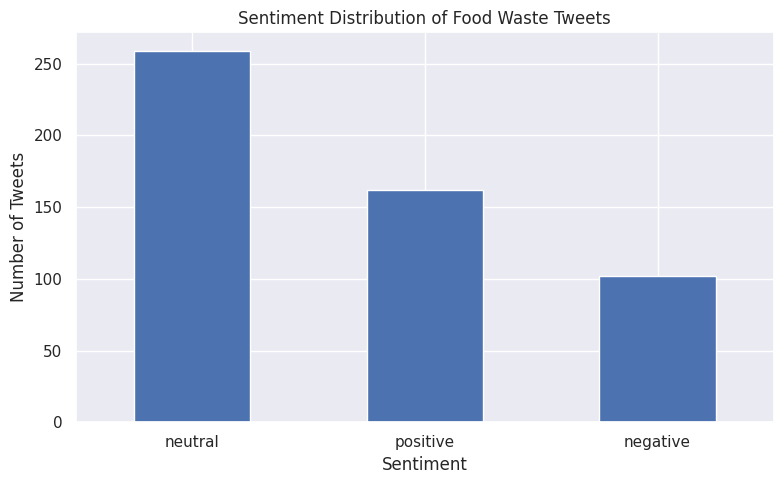

In [ ]:
import matplotlib.pyplot as plt

df_food_waste["sentiment"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Sentiment Distribution of Food Waste Tweets")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Visual representation of the tabular data above

###Zero-shot NLP

In [ ]:
df_food_waste_sample = df_food_waste.head(50).copy()
candidate_labels = [
    "food waste",
    "composting",
    "recycling",
    "consumer behaviour"
]

from transformers import pipeline

# Faster zero-shot model run
topic_model = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli"
)

candidate_labels = [
    "food waste",
    "composting",
    "recycling",
    "consumer behaviour"
]

def get_topic(text):
    try:
        result = topic_model(
            str(text)[:256],   # shorter text = faster
            candidate_labels
        )
        return result["labels"][0]
    except:
        return "error"

# Run only on sample
df_food_waste_sample["topic"] = df_food_waste_sample["Text"].apply(get_topic)

print(df_food_waste_sample[["Text", "topic"]].head(10))

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

                                                  Text               topic
8    24 27 eu countries developed circular economy ...           recycling
10   india wastes 40 food causing significant econo...          food waste
43   circular economy rethinking waste moving linea...           recycling
44   meet committee powering zero waste stories ban...  consumer behaviour
59   pillar iv africas green minerals strategy dedi...           recycling
110  leading scotlands journey circular economy hel...           recycling
168  72 100b tons materials world consumes every ye...               error
203  five key sectors targeted eus circular economy...  consumer behaviour
251  supply chain drive real social impact amp clai...               error
350  green practices key business successreduce was...               error


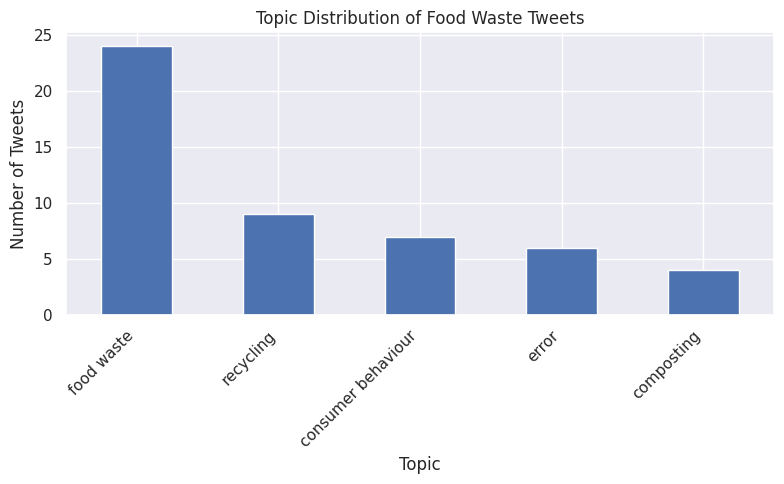

In [ ]:
topic_counts = df_food_waste_sample["topic"].value_counts()

plt.figure(figsize=(8,5))
topic_counts.plot(kind="bar")

plt.title("Topic Distribution of Food Waste Tweets")
plt.xlabel("Topic")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

* **Food waste** is the dominant topic, with the highest number of tweets (24), showing that direct discussions about food disposal, leftovers, and waste reduction are the main focus of public conversation.

* **Recycling (9)** is the second most discussed topic, indicating that users strongly connect food waste with recycling practices such as composting, reuse, and sustainable disposal methods.

* **Consumer behaviour (7)** shows that people also discuss personal habits, shopping choices, and overconsumption as important causes of food waste.

* **Composting (4)** appears less frequently but still highlights awareness of practical waste reduction solutions at the household and community level.

* The presence of **error (6)** suggests that some tweets could not be properly classified by the zero-shot model, likely due to unclear text, short content, or preprocessing issues.

* Overall, the topic distribution shows that Twitter discussions around food waste focus mainly on direct waste reduction, supported by related conversations on recycling and responsible consumer behaviour.


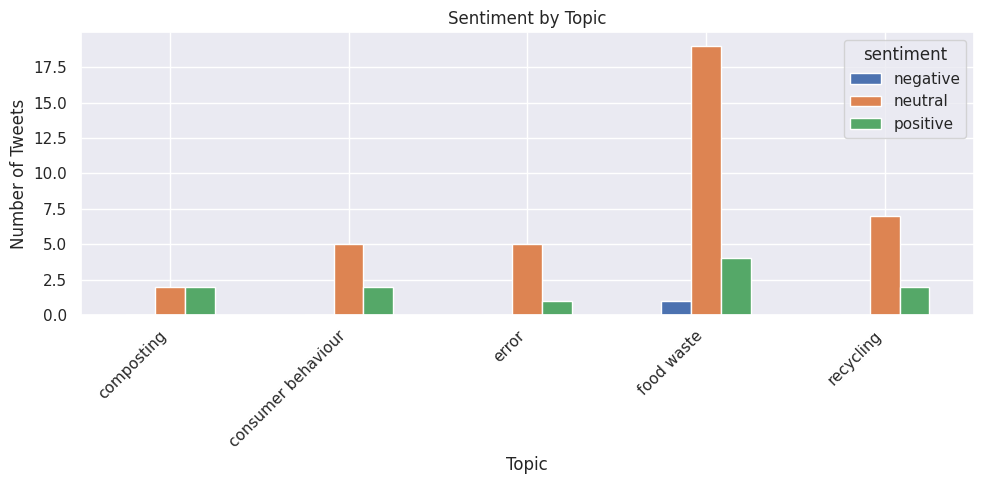

In [ ]:
sentiment_topic = pd.crosstab(
    df_food_waste_sample["topic"],
    df_food_waste_sample["sentiment"]
)

sentiment_topic.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Sentiment by Topic")
plt.xlabel("Topic")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

* The **food waste** topic has the highest number of tweets across all sentiment categories, with neutral sentiment dominating strongly. This shows that most discussions are informational, focused on awareness, reporting, and sharing sustainability practices rather than strong emotional opinions.

* Positive sentiment is also visible in the food waste category, suggesting public support for reducing waste, sustainable eating, and responsible consumption habits.

* Negative sentiment is very low across all topics, indicating that criticism exists but is not the dominant tone of discussion. Negative tweets are mainly related to concerns about wasteful behaviour or poor food management.

* **Recycling** and **consumer behaviour** also show mostly neutral and positive sentiment, which suggests that users discuss these topics constructively, especially around reuse, composting, and improving personal consumption habits.

* **Composting** has a smaller number of tweets but shows balanced neutral and positive sentiment, reflecting practical household-level sustainability actions.

* The **error** category appears due to model classification issues and should not be interpreted as a real topic.

* Overall, the sentiment-by-topic analysis shows that food waste discussions are largely awareness-driven and solution-focused, with positive engagement toward sustainability practices and limited negative reactions.


## Clustering

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=1000,
    stop_words="english"
)

X = vectorizer.fit_transform(df_food_waste["Text"])

print("TF-IDF shape:", X.shape)

TF-IDF shape: (523, 1000)


In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df_food_waste["cluster"] = kmeans.fit_predict(X)

print(df_food_waste[["Text", "cluster"]].head(10))
print(df_food_waste["cluster"].value_counts())

                                                  Text  cluster
8    24 27 eu countries developed circular economy ...        2
10   india wastes 40 food causing significant econo...        2
43   circular economy rethinking waste moving linea...        1
44   meet committee powering zero waste stories ban...        3
59   pillar iv africas green minerals strategy dedi...        1
110  leading scotlands journey circular economy hel...        2
168  72 100b tons materials world consumes every ye...        3
203  five key sectors targeted eus circular economy...        3
251  supply chain drive real social impact amp clai...        3
350  green practices key business successreduce was...        1
cluster
2    247
3    121
1     93
0     62
Name: count, dtype: int64


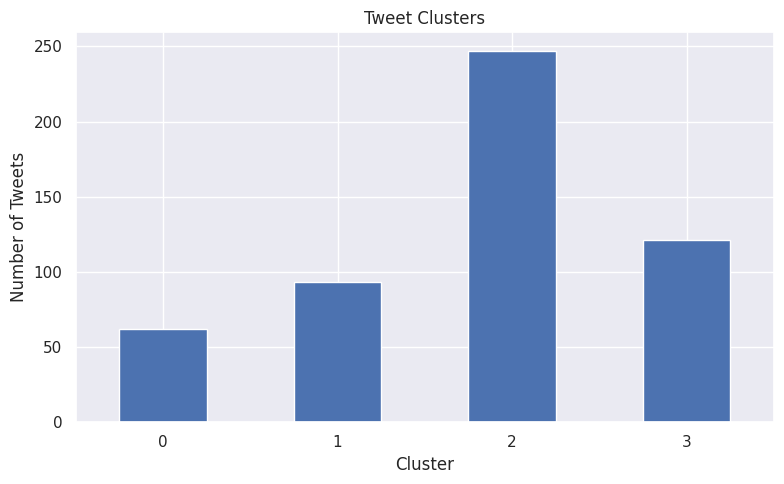

In [ ]:
import matplotlib.pyplot as plt

df_food_waste["cluster"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Tweet Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
for i in range(4):
    print(f"\n===== Cluster {i} Sample Tweets =====")
    print(
        df_food_waste[df_food_waste["cluster"] == i]["Text"]
        .head(5)
        .to_string(index=False)
    )


===== Cluster 0 Sample Tweets =====
power planetmay earth day inspire us reduce was...
food waste creates greenhouse gases every stage...
continue global initiatives earthday inhouse ur...
irony though look beyond green washing language...
1 week gountil world unites stopfoodwasteday bi...

===== Cluster 1 Sample Tweets =====
circular economy rethinking waste moving linear...
pillar iv africas green minerals strategy dedic...
green practices key business successreduce wast...
happy earthday national restaurant associationf...
zerowaste sustainable throughcommunityled recyc...

===== Cluster 2 Sample Tweets =====
24 27 eu countries developed circular economy s...
india wastes 40 food causing significant econom...
leading scotlands journey circular economy help...
2025 menus change leadership summit know join m...
know planning meals save money amp reduce food ...

===== Cluster 3 Sample Tweets =====
meet committee powering zero waste stories bank...
72 100b tons materials world consume

In [ ]:
import pandas as pd

cluster_sentiment = pd.crosstab(
    df_food_waste["cluster"],
    df_food_waste["sentiment"]
)

print(cluster_sentiment)

sentiment  negative  neutral  positive
cluster                               
0                 8       27        27
1                 5       50        38
2                76      120        51
3                13       62        46


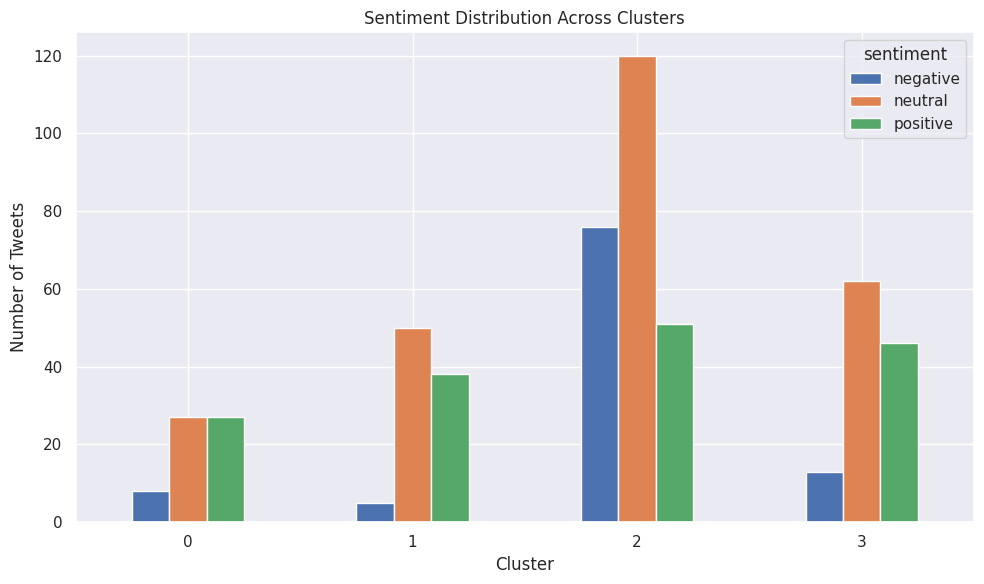

In [ ]:
import matplotlib.pyplot as plt

cluster_sentiment.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Sentiment Distribution Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

* **Cluster 2** contains the highest number of tweets across all sentiment categories, especially neutral (120) and negative (76). This suggests that this cluster represents the main discussion area, likely focused on broad food waste awareness, reporting, and criticism of unsustainable practices.

* The high neutral sentiment in Cluster 2 indicates that many tweets are informational, such as sharing statistics, news, and awareness campaigns, while the relatively high negative sentiment reflects concern about wasteful behaviour and environmental problems.

* **Cluster 3** shows strong neutral (61) and positive (46) sentiment with low negative sentiment, suggesting this cluster may represent solution-focused discussions such as recycling, composting, and sustainable food management practices.

* **Cluster 1** also has low negative sentiment and balanced neutral (50) and positive (38) tweets, indicating constructive discussions around consumer behaviour, responsible shopping, and waste reduction strategies.

* **Cluster 0** has the smallest number of tweets and shows equal neutral and positive sentiment with very little negativity, suggesting a smaller niche discussion around specific sustainability actions or awareness messages.

* Overall, most clusters are dominated by **neutral and positive sentiment**, showing that public discourse around food waste is mainly informative and solution-oriented rather than highly negative. Negative sentiment is concentrated mostly in Cluster 2, where criticism of food waste problems is strongest.


##Random Forest

I am using the entire unfiltered dataset for this analysis

In [ ]:
import pandas as pd

features = df_SDG12[
    [
        "Text_Length",
        "Retweet_Count",
        "Favorite_Count",
        "Reply_Count",
        "Quote_Count"
    ]
].copy()

target = df_SDG12["sentiment"]

print(features.head())
print(target.head())

   Text_Length  Retweet_Count  Favorite_Count  Reply_Count  Quote_Count
0          221              2               2            2            0
1          296              0               1            0            0
2          308              3               9            3            0
3          296              0               2            0            0
4          416              1               3            0            0
0    0.15
1    0.25
2    0.00
3    0.00
4    0.70
Name: sentiment, dtype: float64


In [ ]:
def sentiment_label(score):
    if score < 0:
        return "negative"
    elif score == 0:
        return "neutral"
    else:
        return "positive"

target_class = target.apply(sentiment_label)

print(target_class.value_counts())

sentiment
positive    3448
negative    1053
neutral      772
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(target_class)

print(le.classes_)

['negative' 'neutral' 'positive']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully")

Random Forest trained successfully


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = rf_model.predict(X_test)

print("Accuracy:", round(
    accuracy_score(y_test, y_pred) * 100, 2
), "%")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 59.24 %

Classification Report:

              precision    recall  f1-score   support

           0       0.23      0.13      0.17       216
           1       0.31      0.17      0.22       161
           2       0.67      0.84      0.75       678

    accuracy                           0.59      1055
   macro avg       0.41      0.38      0.38      1055
weighted avg       0.53      0.59      0.55      1055



Text_Length       0.594627
Favorite_Count    0.195360
Retweet_Count     0.113403
Reply_Count       0.066188
Quote_Count       0.030422
dtype: float64


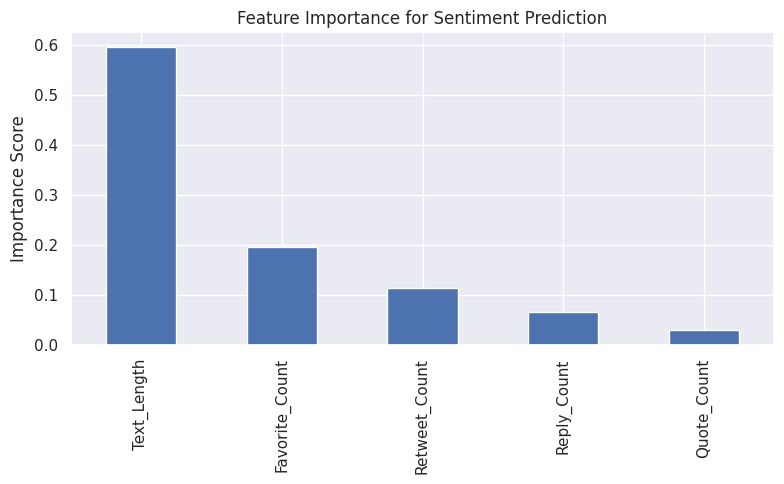

In [ ]:
import matplotlib.pyplot as plt

importance = pd.Series(
    rf_model.feature_importances_,
    index=features.columns
).sort_values(ascending=False)

print(importance)

importance.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Feature Importance for Sentiment Prediction")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

The Random Forest we used on the filtered data frame does not give us good results. So we will be using a better dataset.

In [ ]:
import pandas as pd

# Make sure sentiment is numeric
df_SDG12["sentiment"] = pd.to_numeric(df_SDG12["sentiment"], errors="coerce")

# Your top trigrams list
top_trigrams = [
    "reduce carbon footprint",
    "supply chain traceability",
    "extended producer responsibility",
    "reducing carbon footprint",
    "green supply chain",
    "household waste recycling",
    "reduce food waste",
    "fair trade fair trade"
]

trigram_sentiment_results = []

for trigram in top_trigrams:
    matched_tweets = df_SDG12[
        df_SDG12["Text"].astype(str).str.contains(
            trigram,
            case=False,
            na=False
        )
    ]

    avg_sentiment = matched_tweets["sentiment"].mean()
    tweet_count = len(matched_tweets)

    trigram_sentiment_results.append({
        "trigram": trigram,
        "tweet_count": tweet_count,
        "average_sentiment": avg_sentiment
    })

df_trigram_sentiment = pd.DataFrame(trigram_sentiment_results)

print(df_trigram_sentiment)

                            trigram  tweet_count  average_sentiment
0           reduce carbon footprint           14           0.140054
1         supply chain traceability           99           0.146570
2  extended producer responsibility          107           0.071867
3         reducing carbon footprint            9           0.074509
4                green supply chain           59          -0.027226
5         household waste recycling           37          -0.015691
6                 reduce food waste           37           0.085849
7             fair trade fair trade            0                NaN


In [ ]:
def sentiment_category(score):
    if score > 0.05:
        return "positive"
    elif score < -0.05:
        return "negative"
    else:
        return "neutral"

df_trigram_sentiment["sentiment_label"] = df_trigram_sentiment["average_sentiment"].apply(sentiment_category)

print(df_trigram_sentiment)

                            trigram  tweet_count  average_sentiment  \
0           reduce carbon footprint           14           0.140054   
1         supply chain traceability           99           0.146570   
2  extended producer responsibility          107           0.071867   
3         reducing carbon footprint            9           0.074509   
4                green supply chain           59          -0.027226   
5         household waste recycling           37          -0.015691   
6                 reduce food waste           37           0.085849   
7             fair trade fair trade            0                NaN   

  sentiment_label  
0        positive  
1        positive  
2        positive  
3        positive  
4         neutral  
5         neutral  
6        positive  
7         neutral  


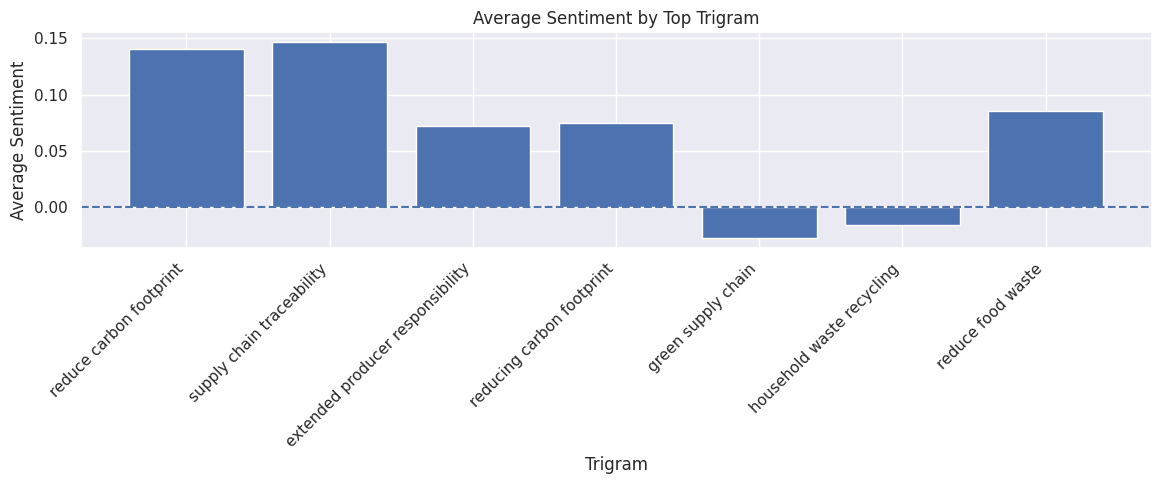

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.bar(
    df_trigram_sentiment["trigram"],
    df_trigram_sentiment["average_sentiment"]
)

plt.title("Average Sentiment by Top Trigram")
plt.xlabel("Trigram")
plt.ylabel("Average Sentiment")
plt.xticks(rotation=45, ha="right")
plt.axhline(0, linestyle="--")

plt.tight_layout()
plt.show()

* **Supply chain traceability** shows the highest positive average sentiment, indicating strong public support for transparency in production, ethical sourcing, and responsible supply chain management.

* **Reduce carbon footprint** and **reducing carbon footprint** also have clearly positive sentiment scores, showing that environmental responsibility and emission reduction are viewed very positively by Twitter users within SDG12 discussions.

* **Extended producer responsibility** has positive sentiment as well, suggesting that users support the idea that companies should be accountable for the full lifecycle impact of their products.

* **Reduce food waste** also receives positive sentiment, confirming that food waste reduction is widely seen as an important and favorable sustainability action.

* **Green supply chain** and **household waste recycling** show slightly negative sentiment scores. This may reflect criticism of implementation challenges, lack of effective recycling systems, or dissatisfaction with how sustainable supply chain practices are being managed.

* The negative values are relatively small, meaning these topics are not strongly opposed but may involve more concern, frustration, or discussion of practical difficulties rather than direct rejection.

* Overall, the trigram sentiment analysis shows that sustainability themes related to prevention and responsibility (carbon reduction, traceability, food waste reduction) generate stronger positive reactions than operational themes like recycling systems and supply chain execution, where public concerns are slightly higher.
